In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import random

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
class SpeechHMM:
    """Hidden Markov Model for Speech Phoneme Transitions"""
    
    def __init__(self):
        # Define phonemes (hidden states)
        self.phonemes = ['/s/', '/p/', '/ie:/', '/tS/']
        
        # Define observations (acoustic properties)
        self.observations = ['Energy', 'Pitch', 'Duration']
        
        # Initial probabilities (starting with /s/ has probability 1)
        self.initial_probs = {
            '/s/': 1.0,
            '/p/': 0.0,
            '/ie:/': 0.0,
            '/tS/': 0.0
        }
        
        # Transition probabilities (from document)
        self.transition_probs = {
            '/s/': {'/s/': 0.0, '/p/': 1.0, '/ie:/': 0.0, '/tS/': 0.0},
            '/p/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 1.0, '/tS/': 0.0},
            '/ie:/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 0.0, '/tS/': 1.0},
            '/tS/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 0.0, '/tS/': 1.0}
        }
        
        # Emission probabilities (from document)
        self.emission_probs = {
            '/s/': {'Energy': 0.7, 'Pitch': 0.2, 'Duration': 0.1},
            '/p/': {'Energy': 0.5, 'Pitch': 0.3, 'Duration': 0.2},
            '/ie:/': {'Energy': 0.3, 'Pitch': 0.5, 'Duration': 0.2},
            '/tS/': {'Energy': 0.4, 'Pitch': 0.4, 'Duration': 0.2}
        }
    
    def get_transition_matrix(self) -> pd.DataFrame:
        """Convert transition probabilities to DataFrame"""
        matrix = []
        for from_state in self.phonemes:
            row = [self.transition_probs[from_state][to_state] 
                   for to_state in self.phonemes]
            matrix.append(row)
        return pd.DataFrame(matrix, 
                          index=self.phonemes, 
                          columns=self.phonemes)
    
    def get_emission_matrix(self) -> pd.DataFrame:
        """Convert emission probabilities to DataFrame"""
        matrix = []
        for phoneme in self.phonemes:
            row = [self.emission_probs[phoneme][obs] 
                   for obs in self.observations]
            matrix.append(row)
        return pd.DataFrame(matrix, 
                          index=self.phonemes, 
                          columns=self.observations)
    
    def get_initial_probs_series(self) -> pd.Series:
        """Convert initial probabilities to Series"""
        return pd.Series(self.initial_probs)

# Initialize HMM
hmm = SpeechHMM()
print("HMM initialized successfully!")

HMM initialized successfully!


In [4]:
def display_hmm_parameters(hmm: SpeechHMM):
    """Display all HMM parameters in a neat format"""
    
    print("="*60)
    print("HIDDEN MARKOV MODEL FOR SPEECH PHONEME TRANSITIONS")
    print("="*60)
    
    print("\n1. INITIAL PROBABILITIES")
    print("-" * 40)
    initial_df = pd.DataFrame({
        'Phoneme': hmm.phonemes,
        'Initial Probability': [hmm.initial_probs[p] for p in hmm.phonemes]
    })
    print(initial_df.to_string(index=False))
    
    print("\n\n2. TRANSITION PROBABILITIES")
    print("-" * 40)
    print("(Probability of transitioning from row phoneme to column phoneme)\n")
    transition_matrix = hmm.get_transition_matrix()
    print(transition_matrix)
    
    print("\n\n3. EMISSION PROBABILITIES")
    print("-" * 40)
    print("(Probability of observing acoustic property given a phoneme)\n")
    emission_matrix = hmm.get_emission_matrix()
    print(emission_matrix)
    
    print("\n" + "="*60)

# Display parameters
display_hmm_parameters(hmm)

HIDDEN MARKOV MODEL FOR SPEECH PHONEME TRANSITIONS

1. INITIAL PROBABILITIES
----------------------------------------
Phoneme  Initial Probability
    /s/                  1.0
    /p/                  0.0
  /ie:/                  0.0
   /tS/                  0.0


2. TRANSITION PROBABILITIES
----------------------------------------
(Probability of transitioning from row phoneme to column phoneme)

       /s/  /p/  /ie:/  /tS/
/s/    0.0  1.0    0.0   0.0
/p/    0.0  0.0    1.0   0.0
/ie:/  0.0  0.0    0.0   1.0
/tS/   0.0  0.0    0.0   1.0


3. EMISSION PROBABILITIES
----------------------------------------
(Probability of observing acoustic property given a phoneme)

       Energy  Pitch  Duration
/s/       0.7    0.2       0.1
/p/       0.5    0.3       0.2
/ie:/     0.3    0.5       0.2
/tS/      0.4    0.4       0.2



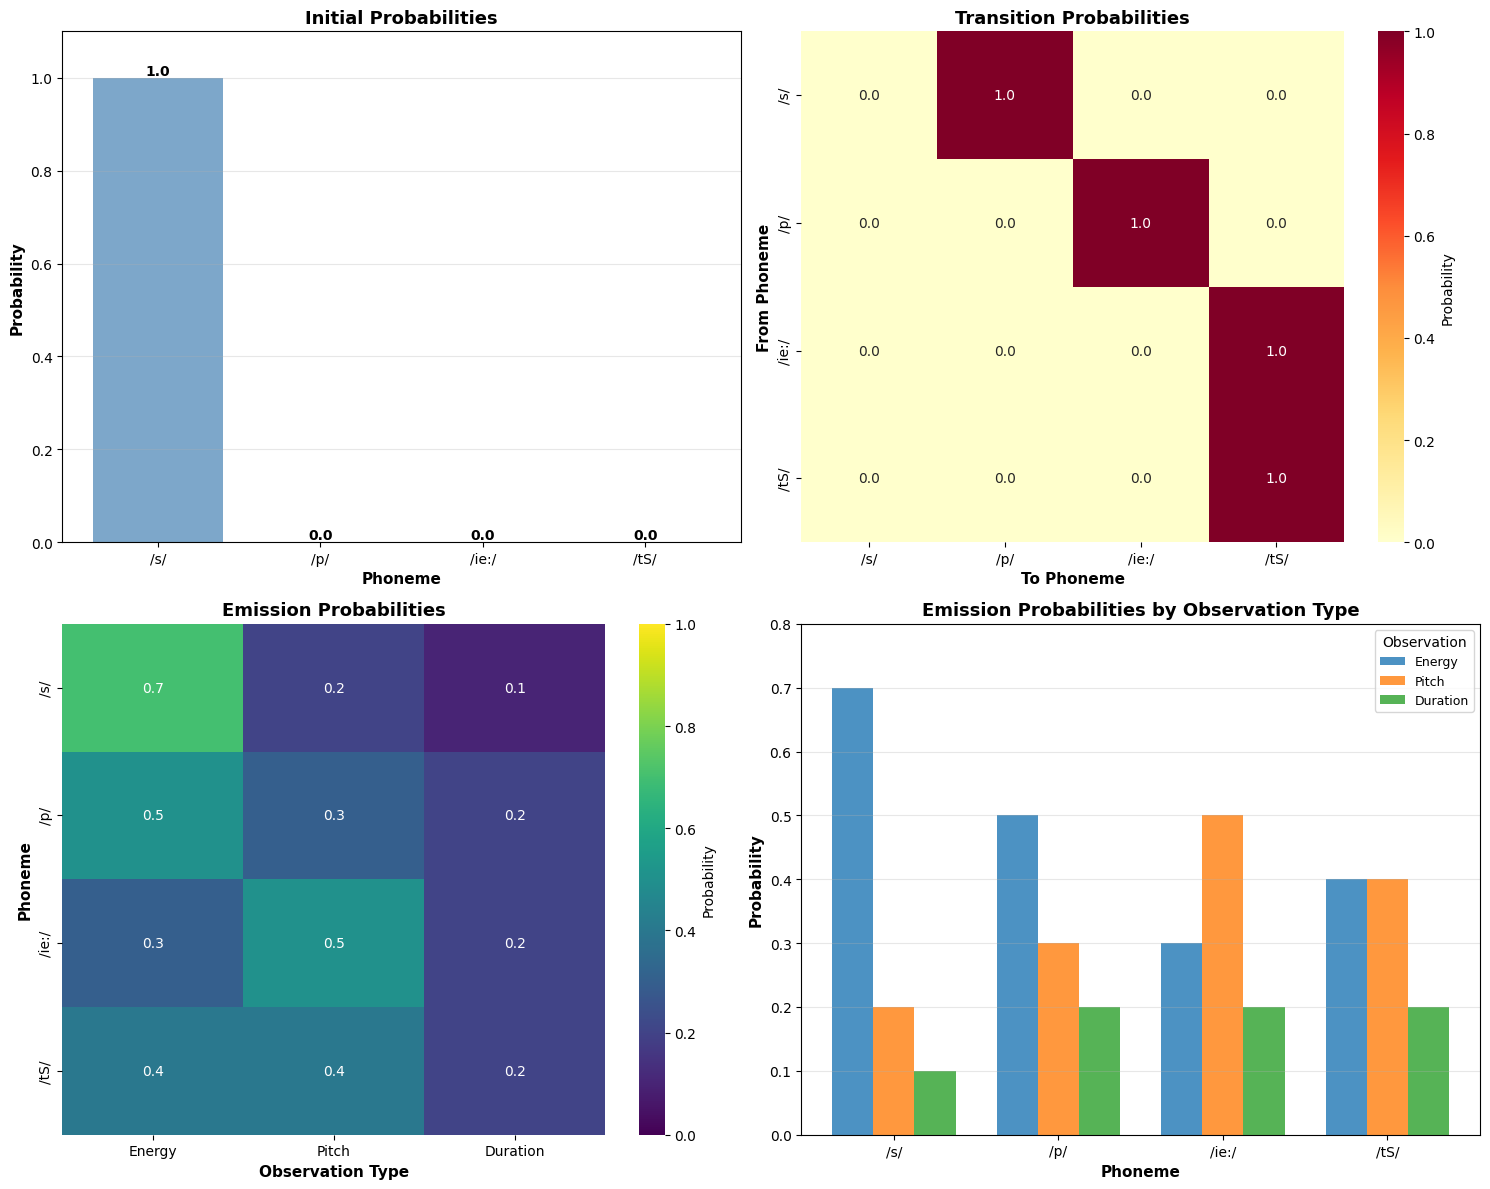

In [5]:
def visualize_hmm(hmm: SpeechHMM):
    """Create comprehensive visualizations of HMM parameters"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Initial Probabilities Bar Chart
    ax1 = axes[0, 0]
    initial_probs_list = [hmm.initial_probs[p] for p in hmm.phonemes]
    bars = ax1.bar(hmm.phonemes, initial_probs_list, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Phoneme', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax1.set_title('Initial Probabilities', fontsize=13, fontweight='bold')
    ax1.set_ylim([0, 1.1])
    ax1.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold')
    
    # 2. Transition Probability Heatmap
    ax2 = axes[0, 1]
    transition_matrix = hmm.get_transition_matrix()
    sns.heatmap(transition_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Probability'}, ax=ax2, vmin=0, vmax=1)
    ax2.set_xlabel('To Phoneme', fontsize=11, fontweight='bold')
    ax2.set_ylabel('From Phoneme', fontsize=11, fontweight='bold')
    ax2.set_title('Transition Probabilities', fontsize=13, fontweight='bold')
    
    # 3. Emission Probability Heatmap
    ax3 = axes[1, 0]
    emission_matrix = hmm.get_emission_matrix()
    sns.heatmap(emission_matrix, annot=True, fmt='.1f', cmap='viridis', 
                cbar_kws={'label': 'Probability'}, ax=ax3, vmin=0, vmax=1)
    ax3.set_xlabel('Observation Type', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Phoneme', fontsize=11, fontweight='bold')
    ax3.set_title('Emission Probabilities', fontsize=13, fontweight='bold')
    
    # 4. Emission Probabilities Grouped Bar Chart
    ax4 = axes[1, 1]
    x = np.arange(len(hmm.phonemes))
    width = 0.25
    
    for i, obs in enumerate(hmm.observations):
        values = [hmm.emission_probs[p][obs] for p in hmm.phonemes]
        ax4.bar(x + i*width, values, width, label=obs, alpha=0.8)
    
    ax4.set_xlabel('Phoneme', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax4.set_title('Emission Probabilities by Observation Type', 
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x + width)
    ax4.set_xticklabels(hmm.phonemes)
    ax4.legend(title='Observation', fontsize=9)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim([0, 0.8])
    
    plt.tight_layout()
    plt.show()

# Generate visualizations
visualize_hmm(hmm)

In [6]:
def generate_sequence(hmm: SpeechHMM) -> Tuple[List[str], List[str]]:
    """
    Generate a sequence of phonemes and corresponding observations
    for the word 'speech'
    """
    
    # Start with initial state
    current_state = np.random.choice(
        hmm.phonemes, 
        p=[hmm.initial_probs[p] for p in hmm.phonemes]
    )
    
    phoneme_sequence = [current_state]
    observation_sequence = []
    
    # Generate observation for initial state
    obs_probs = [hmm.emission_probs[current_state][obs] 
                 for obs in hmm.observations]
    observation = np.random.choice(hmm.observations, p=obs_probs)
    observation_sequence.append(observation)
    
    # Generate subsequent states until we complete the word "speech"
    while len(phoneme_sequence) < 4:
        # Get transition probabilities from current state
        trans_probs = [hmm.transition_probs[current_state][next_state] 
                      for next_state in hmm.phonemes]
        
        # Choose next state
        next_state = np.random.choice(hmm.phonemes, p=trans_probs)
        phoneme_sequence.append(next_state)
        
        # Generate observation for this state
        obs_probs = [hmm.emission_probs[next_state][obs] 
                    for obs in hmm.observations]
        observation = np.random.choice(hmm.observations, p=obs_probs)
        observation_sequence.append(observation)
        
        current_state = next_state
    
    return phoneme_sequence, observation_sequence

# Generate sequence
phoneme_seq, observation_seq = generate_sequence(hmm)

print("\n" + "="*60)
print("GENERATED SEQUENCE FOR 'SPEECH'")
print("="*60)
print(f"\nGenerated phoneme sequence: {phoneme_seq}")
print(f"Corresponding observations: {observation_seq}")
print("\n" + "="*60)


GENERATED SEQUENCE FOR 'SPEECH'

Generated phoneme sequence: [np.str_('/s/'), np.str_('/p/'), np.str_('/ie:/'), np.str_('/tS/')]
Corresponding observations: [np.str_('Energy'), np.str_('Pitch'), np.str_('Energy'), np.str_('Energy')]



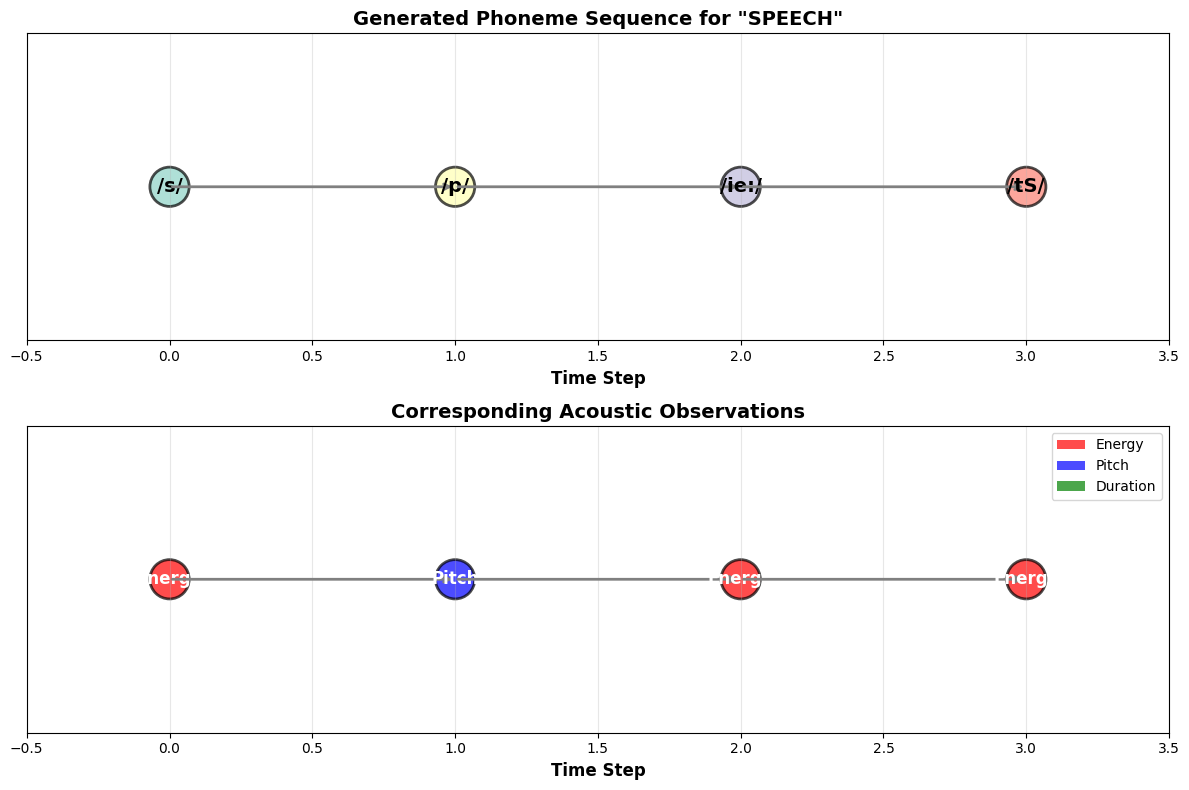

In [7]:
def visualize_sequence(phoneme_seq: List[str], observation_seq: List[str]):
    """Visualize the generated phoneme and observation sequence"""
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Phoneme Sequence
    ax1 = axes[0]
    positions = range(len(phoneme_seq))
    colors = plt.cm.Set3(range(len(phoneme_seq)))
    
    ax1.scatter(positions, [1]*len(phoneme_seq), s=800, c=colors, 
                alpha=0.7, edgecolors='black', linewidth=2)
    
    for i, phoneme in enumerate(phoneme_seq):
        ax1.text(i, 1, phoneme, ha='center', va='center', 
                fontsize=14, fontweight='bold')
        if i < len(phoneme_seq) - 1:
            ax1.annotate('', xy=(i+1, 1), xytext=(i, 1),
                        arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    
    ax1.set_xlim(-0.5, len(phoneme_seq)-0.5)
    ax1.set_ylim(0.5, 1.5)
    ax1.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax1.set_title('Generated Phoneme Sequence for "SPEECH"', 
                  fontsize=14, fontweight='bold')
    ax1.set_yticks([])
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Observation Sequence
    ax2 = axes[1]
    obs_colors = {'Energy': 'red', 'Pitch': 'blue', 'Duration': 'green'}
    colors2 = [obs_colors[obs] for obs in observation_seq]
    
    ax2.scatter(positions, [1]*len(observation_seq), s=800, c=colors2, 
                alpha=0.7, edgecolors='black', linewidth=2)
    
    for i, obs in enumerate(observation_seq):
        ax2.text(i, 1, obs, ha='center', va='center', 
                fontsize=12, fontweight='bold', color='white')
        if i < len(observation_seq) - 1:
            ax2.annotate('', xy=(i+1, 1), xytext=(i, 1),
                        arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    
    ax2.set_xlim(-0.5, len(observation_seq)-0.5)
    ax2.set_ylim(0.5, 1.5)
    ax2.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax2.set_title('Corresponding Acoustic Observations', 
                  fontsize=14, fontweight='bold')
    ax2.set_yticks([])
    ax2.grid(axis='x', alpha=0.3)
    
    # Add legend for observations
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=obs, alpha=0.7)
                      for obs, color in obs_colors.items()]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualize the generated sequence
visualize_sequence(phoneme_seq, observation_seq)

In [8]:
sequence_df = pd.DataFrame({
    'Time Step': range(1, len(phoneme_seq) + 1),
    'Phoneme': phoneme_seq,
    'Observation': observation_seq
})

print("\nSequence Table:")
print(sequence_df.to_string(index=False))


Sequence Table:
 Time Step Phoneme Observation
         1     /s/      Energy
         2     /p/       Pitch
         3   /ie:/      Energy
         4    /tS/      Energy


In [9]:
def hmm_inference(hmm: SpeechHMM, phoneme_seq: List[str], 
                  observation_seq: List[str]):
    """
    Perform inference on the generated HMM sequence
    """
    
    print("\n" + "="*70)
    print("HMM INFERENCE AND ANALYSIS")
    print("="*70)
    
    # 1. Sequence Probability Calculation
    print("\n1. SEQUENCE PROBABILITY CALCULATION")
    print("-" * 70)
    
    # Calculate joint probability of phoneme sequence
    prob_phoneme = hmm.initial_probs[phoneme_seq[0]]
    print(f"   Initial probability P({phoneme_seq[0]}) = {prob_phoneme}")
    
    for i in range(len(phoneme_seq) - 1):
        trans_prob = hmm.transition_probs[phoneme_seq[i]][phoneme_seq[i+1]]
        prob_phoneme *= trans_prob
        print(f"   Transition P({phoneme_seq[i+1]}|{phoneme_seq[i]}) = {trans_prob}")
    
    print(f"\n   Total phoneme sequence probability = {prob_phoneme:.6f}")
    
    # Calculate probability of observations given phonemes
    prob_observation = 1.0
    print(f"\n   Observation probabilities:")
    for i in range(len(observation_seq)):
        emit_prob = hmm.emission_probs[phoneme_seq[i]][observation_seq[i]]
        prob_observation *= emit_prob
        print(f"   P({observation_seq[i]}|{phoneme_seq[i]}) = {emit_prob}")
    
    print(f"\n   Total observation probability = {prob_observation:.6f}")
    
    joint_prob = prob_phoneme * prob_observation
    print(f"\n   Joint probability P(phonemes, observations) = {joint_prob:.8f}")
    
    # 2. Model Characteristics
    print("\n\n2. MODEL CHARACTERISTICS")
    print("-" * 70)
    print(f"   Number of hidden states (phonemes): {len(hmm.phonemes)}")
    print(f"   Number of observable states: {len(hmm.observations)}")
    print(f"   Model type: Deterministic left-to-right HMM")
    print(f"   Word being modeled: 'SPEECH'")
    
    # 3. Emission Analysis
    print("\n\n3. EMISSION PROBABILITY ANALYSIS")
    print("-" * 70)
    for phoneme in hmm.phonemes:
        dominant_obs = max(hmm.emission_probs[phoneme].items(), 
                          key=lambda x: x[1])
        print(f"   {phoneme}: Most likely observation is '{dominant_obs[0]}' "
              f"with probability {dominant_obs[1]}")
    
    # 4. Key Observations
    print("\n\n4. KEY OBSERVATIONS")
    print("-" * 70)
    print(f"   • The model uses a deterministic transition structure")
    print(f"   • Each phoneme transitions to the next with probability 1.0")
    print(f"   • This reflects the sequential nature of speech production")
    print(f"   • /s/ (sibilant) is most likely to emit 'Energy' features")
    print(f"   • /ie:/ (vowel) is most likely to emit 'Pitch' features")
    print(f"   • The final phoneme /tS/ has equal probability for Energy and Pitch")
    
    print("\n" + "="*70)

# Perform inference
hmm_inference(hmm, phoneme_seq, observation_seq)


HMM INFERENCE AND ANALYSIS

1. SEQUENCE PROBABILITY CALCULATION
----------------------------------------------------------------------
   Initial probability P(/s/) = 1.0
   Transition P(/p/|/s/) = 1.0
   Transition P(/ie:/|/p/) = 1.0
   Transition P(/tS/|/ie:/) = 1.0

   Total phoneme sequence probability = 1.000000

   Observation probabilities:
   P(Energy|/s/) = 0.7
   P(Pitch|/p/) = 0.3
   P(Energy|/ie:/) = 0.3
   P(Energy|/tS/) = 0.4

   Total observation probability = 0.025200

   Joint probability P(phonemes, observations) = 0.02520000


2. MODEL CHARACTERISTICS
----------------------------------------------------------------------
   Number of hidden states (phonemes): 4
   Number of observable states: 3
   Model type: Deterministic left-to-right HMM
   Word being modeled: 'SPEECH'


3. EMISSION PROBABILITY ANALYSIS
----------------------------------------------------------------------
   /s/: Most likely observation is 'Energy' with probability 0.7
   /p/: Most likely observ



Running 100 simulations...



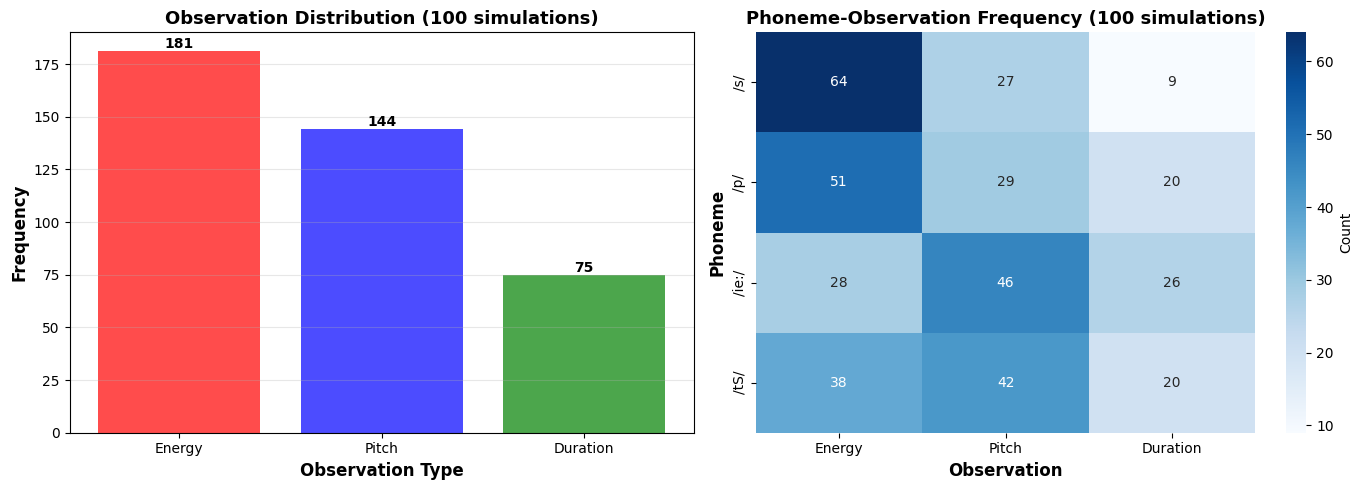


Observation distribution across 100 simulations:
  Energy: 181 times (45.2%)
  Pitch: 144 times (36.0%)
  Duration: 75 times (18.8%)


In [10]:
def run_multiple_simulations(hmm: SpeechHMM, n_simulations: int = 10):
    """Run multiple simulations and analyze observation patterns"""
    
    print(f"\n\nRunning {n_simulations} simulations...\n")
    
    observation_counts = {obs: 0 for obs in hmm.observations}
    phoneme_observation_pairs = []
    
    for i in range(n_simulations):
        phoneme_seq, observation_seq = generate_sequence(hmm)
        phoneme_observation_pairs.append(list(zip(phoneme_seq, observation_seq)))
        
        for obs in observation_seq:
            observation_counts[obs] += 1
    
    # Visualize results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Observation frequency
    ax1 = axes[0]
    obs_names = list(observation_counts.keys())
    obs_values = list(observation_counts.values())
    bars = ax1.bar(obs_names, obs_values, color=['red', 'blue', 'green'], alpha=0.7)
    ax1.set_xlabel('Observation Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title(f'Observation Distribution ({n_simulations} simulations)', 
                  fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    # Phoneme-Observation heatmap
    ax2 = axes[1]
    phoneme_obs_matrix = np.zeros((len(hmm.phonemes), len(hmm.observations)))
    
    for pairs in phoneme_observation_pairs:
        for phoneme, obs in pairs:
            p_idx = hmm.phonemes.index(phoneme)
            o_idx = hmm.observations.index(obs)
            phoneme_obs_matrix[p_idx, o_idx] += 1
    
    sns.heatmap(phoneme_obs_matrix, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=hmm.observations, yticklabels=hmm.phonemes,
                cbar_kws={'label': 'Count'}, ax=ax2)
    ax2.set_xlabel('Observation', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Phoneme', fontsize=12, fontweight='bold')
    ax2.set_title(f'Phoneme-Observation Frequency ({n_simulations} simulations)', 
                  fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nObservation distribution across {n_simulations} simulations:")
    for obs, count in observation_counts.items():
        percentage = (count / (n_simulations * 4)) * 100
        print(f"  {obs}: {count} times ({percentage:.1f}%)")

# Run simulations
run_multiple_simulations(hmm, n_simulations=100)